# Notebook to create and train a CNN for digit classification.

# Importation of the packages

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

I0000 00:00:1777671244.489700   88247 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777671244.494417   88247 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777671244.662749   88247 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777671250.326314   88247 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

# Loading the image dataset

In [11]:
# We use an existing dataset (MNIST) for training and testing
(ds_train, labels_train), (ds_test, labels_test) = tf.keras.datasets.mnist.load_data()

# Normalization of the pixel values (from [0, 255] to [0, 1])
ds_train, ds_test = ds_train / 255.0, ds_test / 255.0

print(f"We got {len(labels_train)} training samples and {len(labels_test)} testing samples.")

print(f"Each image is represented by a {ds_train[0].shape} matrix and the labels are in the range [0, 9].")

We got 60000 training samples and 10000 testing samples.
Each image is represented by a (28, 28) matrix and the labels are in the range [0, 9].


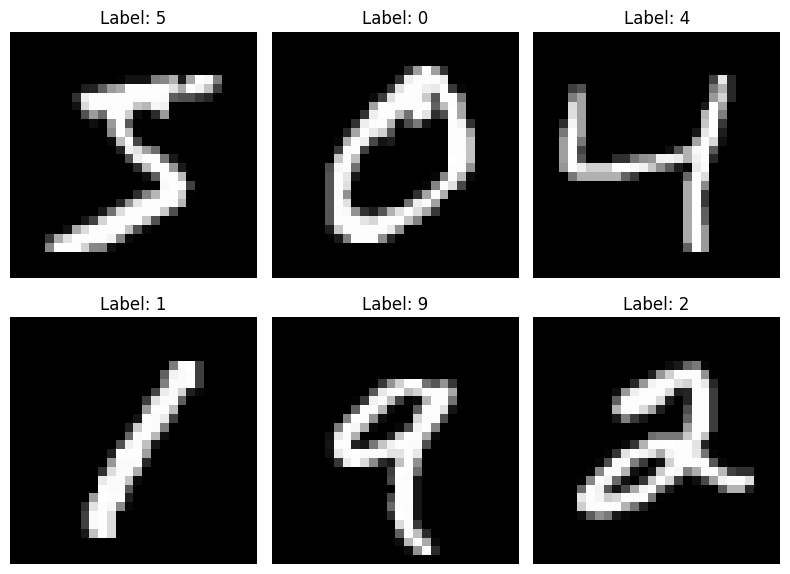

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(8, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(ds_train[i], cmap='gray')
    ax.set_title(f"Label: {labels_train[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Kernel in image processing

A kernel in this case is a convolution matrix applied to an image. Each pixel of the image is recalculated based on its neighbors.

In [13]:
kernels, titles = [], []

# Defining a null kernel (identity)
kernels.append(np.matrix([[0, 0, 0],
                         [0, 1, 0],
                         [0, 0, 0]]))
titles.append("Identity")

# Defining an edge detection kernel 
kernels.append(np.matrix([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]]))
titles.append("Edge Detection")

# Defining a sharpening kernel 
kernels.append(np.matrix([[0, -1, 0],
                          [-1,  5, -1],
                          [0, -1, 0]]))
titles.append("Sharpening")

# Defining a Gaussian blur kernel
kernels.append((1/16) * np.matrix([[1, 2, 1],
                                   [2, 4, 2],
                                   [1, 2, 1]]))
titles.append("Gaussian Blur")

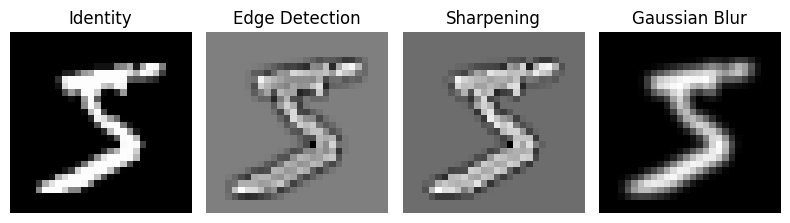

In [ ]:
from scipy.ndimage import convolve

fig, axes = plt.subplots(1, len(kernels), figsize=(8, 6))

img = ds_train[0]  # We take the first image from the training set

for i, ax in enumerate(axes.flatten()):
    # We apply the convolution operation to the image using the defined kernels
    filtered_img = convolve(img, kernels[i], mode='constant', cval=0.0)
    ax.imshow(filtered_img, cmap='gray')
    ax.set_title(f"{titles[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Optimization of the dataset

Adding cache and prefetching to avoid memory bottlenecks:

`.cache()` stores the training images (and their possible preprocessing) in memory, avoiding time loss between epochs because the files are read only once at the beginning.

`.prefetch()` enables parallelization by preparing the next batch during training.

`.shuffle(1000)` prevents the data from arriving in homogeneous batches, which could lead to training issues.

`AUTOTUNE` automatically selects the best configuration for parallelization and buffer size.

In [15]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Conversion numpy -> tf.data.Dataset
ds_train = tf.data.Dataset.from_tensor_slices((ds_train, labels_train))
ds_test  = tf.data.Dataset.from_tensor_slices((ds_test, labels_test))

# Optimization
ds_train = ds_train.batch(BATCH_SIZE).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
ds_test  = ds_test.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)


# Definition of the CNN

Creation of a TensorFlow model containing the CNN, where each layer is added one by one.

`model = tf.keras.Sequential(layer1, layer2 ...)`

##### Convolutional layer
- `layers.Conv2D(32, 3, activation='relu')`:
    - (3,3) or 3 = Size of the convolution kernels
    - 32 = Number of different kernels applied to an image
    - activation='relu' : Negatives values of the activation function = 0

- `layers.MaxPooling2D()` -> Reduction of the image size by grouping pixels into groups of 4 (by default) and keeping the highest value (AveragePooling2D() is also possible).

- `layers.Flatten()`: Conversion of the 2D map into a 1D vector (because the following dense layers do not accept 2D inputs). i.e, if there is 64 matrices 5x5 after the convolutional block n°2, it is converted into a vector of 64×5×5 = 1600 elements.

- `layers.Dense(128, activation='relu')`: A dense layer means that every neuron from the previous layer (1600 values) is connected to the 128 neurons of the current layer, resulting in a weighted sum of their values.

- `layers.Dropout(0.3)`: During training, 30% of the neurons of the previous layer (here dense) are randomly deactivated. It makes the network more robust because it does not rely too heavily on specific neurons. Dropout is automatically deactivated during prediction phases.

- The final layer is a dense one composed of 10 neurons (one for each digit) !

In [18]:
model = tf.keras.Sequential([

    # Convolutif block n°1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolutif block n°2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes (0 to 9)
])

# Compilation

ompilation defines how the model behaves during training.

- `optimizer='adam'`: Defines how the weights are updated after each batch. Adam is an algorithm among many other.

- `loss='sparse_categorical_crossentropy'`: Defines the objective function that the model tries to minimize. It is the function that compares the prediction of the model to the real value/label. (Bad prediction = high loss).

- `metrics=['accuracy']`: Defines the information available to evaluate the training process (it doesn't influence the process).

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("model.h5", save_best_only=True)
]

epochs = 10

history = model.fit(
    ds_train,
    validation_data=ds_test,
    callbacks=callbacks,
    epochs=epochs,
)

Epoch 1/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9972 - loss: 0.0089

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9970 - loss: 0.0089 - val_accuracy: 0.9933 - val_loss: 0.0299
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9969 - loss: 0.0103

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9926 - val_loss: 0.0288
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9971 - loss: 0.0084 - val_accuracy: 0.9919 - val_loss: 0.0380
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9968 - loss: 0.0096 - val_accuracy: 0.9916 - val_loss: 0.0400
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9977 - loss: 0.0072 - val_accuracy: 0.9923 - val_loss: 0.0359
